In [1]:
# from utils_data import *

import os
# import re
import glob
import json

import pandas as pd
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns

import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

import rasterio
from sklearn.preprocessing import StandardScaler

import rasterio
from rasterio.plot import show

##### set dataframe display options
pd.options.display.float_format = '{:.4f}'.format     # show decimal format (not scientific notation
pd.set_option('display.max_columns', None)            # display all columns

# Geography

In [ ]:

patch_path = r'../data/earthscape_patches.geojson'

gdf = gpd.read_file(patch_path)

mask = (gdf['patch_id'].str.contains('hv')) | (gdf['patch_id'].str.contains('sonora'))

gdf_hardin = gdf[mask].copy()

gdf_warren = gdf[~mask]

geom1 = gdf_hardin.geometry.union_all()
geom2 = gdf_warren.geometry.union_all()

# Step 2: compute centroids
cent1 = geom1.centroid
cent2 = geom2.centroid

# Step 3: compute distance in feet
dist_ft = cent1.distance(cent2)

# Convert to km (1 ft = 0.0003048 km)
dist_km = dist_ft * 0.0003048

print(f"Distance between centroids: {dist_km:.3f} km")

# Modalities

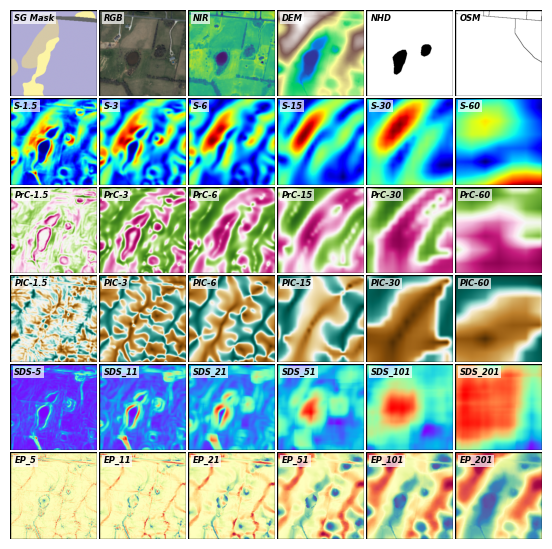

In [ ]:

# warren county modalities example...
patches_dir = r'../data/warren/patches_warren'
# random_patch = np.random.choice(gdf_warren['patch_id'], 1).item()
random_patch = '256_50_21983'
# output_path = f"../data/warren_{random_patch}_modalities.jpg"


# hardin county modalities example...
# patches_dir = r'../data/patches_hardin'
# random_patch = 'hv_256_50_548'
# output_path = f"../data/hardin_{random_patch}_modalities.jpg"



# SG map colors...
geo_meta_path = r'../data/warren/class_mapping.json'
with open(geo_meta_path, 'r') as meta:
    geo_meta = json.load(meta)
colors = {'af1': '#636566', 
          'Qal': '#fdf5a4', 
          'Qaf': '#ffa1db', 
          'Qat': '#f9e465', 
          'Qc': '#d6c9a7', 
          'Qca': '#c49d83', 
          'Qr': '#b0acd6'}
cmap = ListedColormap([colors[symbol] for symbol in geo_meta.keys()])



# prepare rgb or nir+gb (false color) image
rgb_image = []
for image in [f"{patches_dir}/{random_patch}_aerialr.tif", f"{patches_dir}/{random_patch}_aerialg.tif", f"{patches_dir}/{random_patch}_aerialb.tif"]:
    with rasterio.open(image) as src:
        data = src.read(1)
        rgb_image.append(data)
rgb_image = np.dstack(rgb_image) / 255


# plot images...
images_per_row = 6
subplot_width = 6.875 / images_per_row  
subplot_height = 6.875 / images_per_row 
fig, ax = plt.subplots(nrows=6, ncols=images_per_row, figsize=(images_per_row * subplot_width, 6 * subplot_height))
plt.subplots_adjust(hspace=0.02, wspace=0.02)
ax = ax.ravel()


# plot geology mask...
with rasterio.open(f"{patches_dir}/{random_patch}_geology.tif") as src:
    show(src, ax=ax[0], cmap=cmap, vmin=1, vmax=7)


# plot rgb or nir+gb...
ax[1].imshow(rgb_image)


# plot additional images...
additional = ['aerialnir.tif', 'dem.tif', 
              'nhd.tif', 'osm.tif',
              'slope.tif', 'slope_10.tif', 'slope_20.tif', 'slope_50.tif', 'slope_100.tif', 'slope_200.tif',
              'procurv.tif', 'procurv_10.tif', 'procurv_20.tif', 'procurv_50.tif', 'procurv_100.tif', 'procurv_200.tif',
              'plancurv.tif', 'plancurv_10.tif', 'plancurv_20.tif', 'plancurv_50.tif', 'plancurv_100.tif', 'plancurv_200.tif',
              'stdslope_5x5.tif', 'stdslope_11x11.tif', 'stdslope_21x21.tif', 'stdslope_51x51.tif', 'stdslope_101x101.tif', 'stdslope_201x201.tif',
              'ep_5x5.tif', 'ep_11x11.tif', 'ep_21x21.tif', 'ep_51x51.tif', 'ep_101x101.tif', 'ep_201x201.tif']

color_maps = ['viridis', 'terrain', 
              'binary', 'binary',
              'jet', 'jet', 'jet', 'jet', 'jet', 'jet',
              'PiYG', 'PiYG', 'PiYG', 'PiYG', 'PiYG', 'PiYG', 
              'BrBG', 'BrBG', 'BrBG', 'BrBG', 'BrBG', 'BrBG', 
              'rainbow', 'rainbow', 'rainbow', 'rainbow', 'rainbow', 'rainbow', 
              'Spectral_r', 'Spectral_r', 'Spectral_r', 'Spectral_r', 'Spectral_r', 'Spectral_r', ]

for idx, (image, cmap2) in enumerate(zip(additional, color_maps), start=2):

    with rasterio.open(f"{patches_dir}/{random_patch}_{image}") as src:
        data = src.read(1)
        im = ax[idx].imshow(data, cmap=cmap2)


# plot labels...
for idx, title in enumerate(['SG Mask', 'RGB', 'NIR', 'DEM', 
                             'NHD', 'OSM', 
                             'S-1.5', 'S-3', 'S-6', 'S-15', 'S-30', 'S-60', 
                             'PrC-1.5', 'PrC-3', 'PrC-6', 'PrC-15', 'PrC-30', 'PrC-60', 
                             'PlC-1.5', 'PlC-3', 'PlC-6', 'PlC-15', 'PlC-30', 'PlC-60', 
                             'SDS-5', 'SDS_11', 'SDS_21', 'SDS_51', 'SDS_101', 'SDS_201', 
                             'EP_5', 'EP_11', 'EP_21', 'EP_51', 'EP_101', 'EP_201'], start=0):
    ax[idx].set_title(title, style='italic', weight='bold', size=6, y=0.78, x=0.05, loc='left', bbox=dict(facecolor='white', edgecolor='none', pad=1.0, alpha=0.7))



for axes in ax:
    axes.set_axis_off()
    rect = patches.Rectangle((0, 0), 1, 1, transform=axes.transAxes, linewidth=1, edgecolor='black', facecolor='none')
    axes.add_patch(rect)


# plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()

# Class Frequency

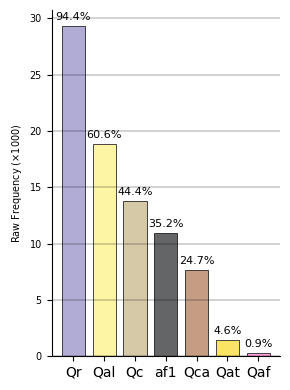

In [20]:

areas_path = r'../data/earthscape_areas.csv'
areas = pd.read_csv(areas_path)

class_counts = (areas[areas.columns[1:]] > 0).sum()
class_counts = class_counts.sort_values(ascending=False)


colors = {'af1': '#636566', 
          'Qal': '#fdf5a4', 
          'Qaf': '#ffa1db', 
          'Qat': '#f9e465', 
          'Qc': '#d6c9a7', 
          'Qca': '#c49d83', 
          'Qr': '#b0acd6'}



fig, ax = plt.subplots(figsize=(3,4))

bars = ax.bar(x=class_counts.index, height=class_counts, edgecolor='k', linewidth=0.5, facecolor=[colors[c] for c in class_counts.index], width=0.75)

percentages = class_counts / len(areas) * 100
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    ax.annotate(f"{pct:.1f}%", xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)
    

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)

ax.set_ylabel(r'Raw Frequency ($\times 1000$)', fontsize=7)
ax.set_yticks(range(0,30001, 5000))
ax.set_yticklabels(['0', '5', '10', '15', '20', '25', '30'], fontsize=7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='k', linestyle='-', linewidth=0.25)


output_path = r'/Users/matthew/Desktop/class_freq.svg'
plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.tight_layout()
plt.show()

In [18]:
areas

,patch_id,af1,Qal,Qaf,Qat,Qc,Qca,Qr
0,hv_256_50_1,0.0000,0.0873,0.0000,0.0000,0.3955,0.4010,0.1163
1,hv_256_50_2,0.0000,0.1318,0.0000,0.0000,0.3443,0.3637,0.1603
2,hv_256_50_3,0.0000,0.1433,0.0000,0.0000,0.4995,0.2060,0.1512
3,hv_256_50_4,0.0000,0.0409,0.0000,0.0000,0.5950,0.1498,0.2143
4,hv_256_50_5,0.0000,0.0010,0.0000,0.0000,0.5901,0.1016,0.3072
...,...,...,...,...,...,...,...,...
31013,sonora_256_50_3722,0.0808,0.0457,0.0000,0.0000,0.0000,0.0000,0.8735
31014,sonora_256_50_3723,0.0778,0.0434,0.0000,0.0000,0.0000,0.0000,0.8789
31015,sonora_256_50_3724,0.0514,0.0783,0.0000,0.0000,0.0000,0.0000,0.8703
31016,sonora_256_50_3725,0.0234,0.0738,0.0000,0.0000,0.0000,0.0000,0.9029


# Class Area

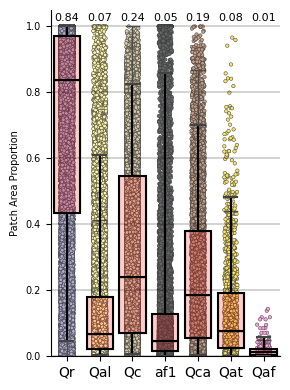

In [12]:

areas_path = r'../data/earthscape_areas.csv'
areas = pd.read_csv(areas_path)

# all class columns (assuming col 0 is patch_id)
class_cols = areas.columns[1:]

# total SG area per patch
areas['total_area'] = areas[class_cols].sum(axis=1)

# long format: one row per patch/class
long = areas.melt(
    id_vars=['patch_id', 'total_area'],
    value_vars=class_cols,
    var_name='class',
    value_name='area'
)

# keep only classes actually present in the patch
long = long[long['area'] > 0].copy()

# proportion of patch area in that class
long['prop'] = long['area'] / long['total_area']

order = (long.groupby('class')['prop'].median().sort_values(ascending=False).index)



fig, ax = plt.subplots(figsize=(3,4))

# 1) jitter / strip points (underneath the boxplot)
sns.stripplot(data=long, x='class', y='prop', jitter=0.2, size=2.5, order=class_counts.index, hue='class', palette=colors, linewidth=0.35, ax=ax, zorder=1)

# 2) hollow boxplot over top
sns.boxplot(data=long, x='class', y='prop', showcaps=True, showfliers=False,
            boxprops={'facecolor': 'red', 'alpha':0.2},
            order=class_counts.index, ax=ax, zorder=2)

# # 2) hollow boxplot over top
# sns.boxplot(data=long, x='class', y='prop', showcaps=True, showfliers=False, whis=(5, 95), 
#             boxprops={'facecolor': 'none', 'edgecolor': 'k', 'linewidth': 1.5}, 
#             whiskerprops={'linewidth': 1.5, 'color': 'k'}, capprops={'linewidth': 1.5},
#             medianprops={'color': 'k', 'linewidth': 1.5},
#             order=order, ax=ax, zorder=3)

sns.boxplot(data=long, x='class', y='prop', showcaps=True, showfliers=False, whis=(5, 95), 
            boxprops={'facecolor': 'none', 'edgecolor': 'k', 'linewidth': 1.5}, 
            whiskerprops={'linewidth': 1.5, 'color': 'k'}, capprops={'linewidth': 1.5},
            medianprops={'color': 'k', 'linewidth': 1.5},
            order=class_counts.index, ax=ax, zorder=3)



top_y = 1.01   # slightly above the highest point; adjust as needed
x_positions = ax.get_xticks()
medians = long.groupby('class')['prop'].median()

for x, cls in zip(x_positions, class_counts.index):
    m = medians[cls]
    ax.annotate(
        f"{m:.2f}",            # or f"{m*100:.0f}%" for percent
        xy=(x, top_y),
        ha="center",
        va="bottom",
        fontsize=8
    )



ax.set_ylim(0,1.05)

ax.set_xlabel('')
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)

ax.set_ylabel(r'Patch Area Proportion', fontsize=7)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='k', linestyle='-', linewidth=0.25)


output_path = r'/Users/matthew/Desktop/class_area.svg'
plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.tight_layout()
plt.show()


# Geographic Imbalance Map

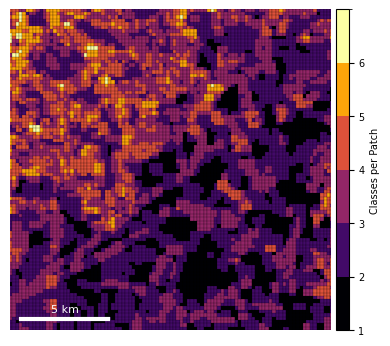

In [7]:

patch_path = r'../data/earthscape_patches.geojson'
gdf = gpd.read_file(patch_path)

areas_path = r'../data/earthscape_areas.csv'
areas = pd.read_csv(areas_path)
areas['total_classes'] = (areas[areas.columns[1:]] > 0).sum(axis=1)

gdf_areas = gdf.merge(areas, on='patch_id')



fig, ax = plt.subplots(figsize=(4,4))

# discrete colormap for integer total_classes
values = gdf_areas['total_classes']
classes = sorted(values.unique())

cmap = mpl.cm.viridis
cmap = mpl.cm.inferno

bounds = np.arange(min(classes), max(classes) + 2)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

# plot
gdf_areas.plot(
    column='total_classes',
    cmap=cmap,
    norm=norm,
    ax=ax,
    linewidth=0.15, edgecolor='k')

ax.set_xlim(4.67e6, 4.73e6)
ax.set_ylim(3.48e6, 3.54e6)
ax.set_axis_off()

# attach colorbar axis to the right, same height
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.05)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax, boundaries=bounds, ticks=classes)
cbar.set_label("Classes per Patch", fontsize=7)
cbar.set_ticklabels([1, 2, 3, 4, 5, 6], fontsize=7)


# ---------------------------------------------------------------------
# *** REVISION: Add manual 5 km scale bar ***
# CRS = EPSG:3089 → units = feet
# 5 km = 5000 m = 5000 / 0.3048 = 16404.2 ft
scale_length_ft = 16404.2   # 5 km in feet

# choose a location inside your current extent (lower left)
x0 = 4.67e6 + 2000      # slight inset from edge (adjust if needed)
y0 = 3.48e6 + 2000

# draw scale bar line
ax.plot([x0, x0 + scale_length_ft], [y0, y0], color='white', linewidth=3)

# label it "5 km"
ax.text(x0 + scale_length_ft/2, y0 + 1000, "5 km", color='white', ha='center', va='bottom', fontsize=8)
# ---------------------------------------------------------------------


output_path = r'/Users/matthew/Desktop/spatial_imbalance_map.svg'
plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.tight_layout()
plt.show()


# Class Patch Histogram

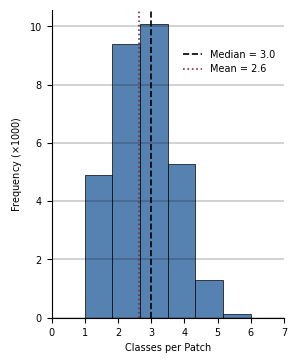

In [8]:

areas_path = r'../data/earthscape_areas.csv'
areas = pd.read_csv(areas_path)
areas['total_classes'] = (areas[areas.columns[1:]] > 0).sum(axis=1)

fig, ax = plt.subplots(figsize=(3,4))

# ax.hist(areas['total_classes'], bins=6, align='mid', linewidth=0.5, edgecolor='k', facecolor='#456882')
ax.hist(areas['total_classes'], bins=6, align='mid', linewidth=0.5, edgecolor='k', facecolor='#5682B1')


median_val = np.median(areas['total_classes'])
mean_val = np.mean(areas['total_classes'])

# --- vertical lines ---
ax.axvline(median_val, color='k', linestyle='--', linewidth=1.2, label=f"Median = {median_val:.1f}")
ax.axvline(mean_val, color='#842A3B', linestyle=':', linewidth=1.2, label=f"Mean = {mean_val:.1f}")

# --- legend (small + unobtrusive) ---
leg = ax.legend(frameon=False, fontsize=7, loc='upper right', bbox_to_anchor=(1,0.9))
# for text in leg.get_texts():
#     text.set_ha('left')



ax.set_xlim(0, 7)
ax.set_xticks(np.arange(0,8,1))
ax.set_xticklabels([0, 1, 2, 3, 4, 5, 6, 7], fontsize=7)
ax.set_xlabel('Classes per Patch', fontsize=7)

ax.set_yticks(np.arange(0,10200, 2000))
ax.set_yticklabels([int(i/1000) for i in np.arange(0,10200, 2000)], fontsize=7)
ax.set_ylabel(r'Frequency ($\times1000$)', fontsize=7)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='k', linestyle='-', linewidth=0.25)


output_path = r'/Users/matthew/Desktop/class_imbalance_hist.svg'
plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()

# Co-occurrence Matrix

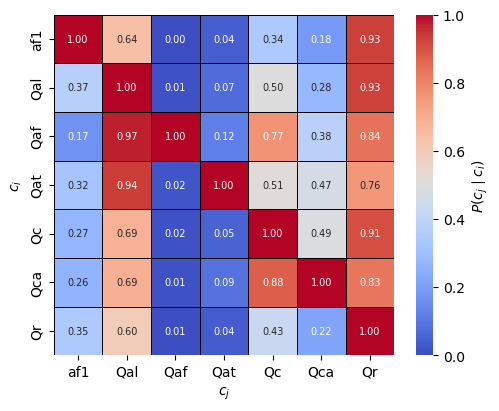

In [9]:
areas_path = r'../data/earthscape_areas.csv'
areas = pd.read_csv(areas_path)
areas['total_classes'] = (areas[areas.columns[1:]] > 0).sum(axis=1)

# presence / co-occurrence
class_cols = areas.columns[1:-1]   # all class columns except patch_id + total_classes
presence = (areas[class_cols] > 0).astype(int)

co_matrix = presence.T.dot(presence)                      
co_norm = co_matrix.div(np.diag(co_matrix), axis=0)       # P(c_j | c_i)

# --- plot ---
fig, ax = plt.subplots(figsize=(5,4))

sns.heatmap(
    co_norm,
    vmin=0, vmax=1,
    cmap="coolwarm",
    square=True,
    linewidths=0.5,           # cell borders
    linecolor='black',
    annot=True,               # show numbers in cells
    fmt=".2f",                # 2 decimal places
    annot_kws={'fontsize': 7},
    cbar=True,
    cbar_kws={
        'label': r'$P(c_j \mid c_i)$',
        'shrink': 1        # pulls colorbar closer
    },
    ax=ax
)

ax.set_xlabel(r"$c_j$")
ax.set_ylabel(r"$c_i$")



output_path = r'/Users/matthew/Desktop/co-occurrence.svg'
plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)

plt.tight_layout(pad=0.3)
plt.show()


# Class Imbalance Table

In [2]:

areas_path = r'../data/earthscape_areas.csv'
areas = pd.read_csv(areas_path)
areas['total_classes'] = (areas[areas.columns[1:]] > 0).sum(axis=1)



# ---- Identify class columns ----
# assuming col[0] = patch_id and col[-1] = total_classes
class_cols = areas.columns[1:-1]

# ---- 1 & 2. Count & Percent of patches containing each class ----
counts = (areas[class_cols] > 0).sum()
percents = counts / len(areas) * 100

# ---- Compute per-patch proportions (class area / total area in that patch) ----
total_area = areas[class_cols].sum(axis=1)
proportions = areas[class_cols].div(total_area, axis=0).fillna(0)

# ---- 3 & 4. Mean and SD of area proportions ----
mean_prop = proportions[class_cols].mean()
sd_prop   = proportions[class_cols].std()

# ---- 5. Effective number of samples (Cui et al. style) ----
# Using n_eff = (1 - beta^n) / (1 - beta), suggested beta ≈ 0.9999 for datasets of this size
beta = 0.9999
n_eff = (1 - beta ** counts) / (1 - beta)

# ---- 6. IRLbl (Imbalance Ratio per class) ----
max_count = counts.max()
IRLbl = max_count / counts


# majority area rate...
class_cols = areas.iloc[:, 1:-1]
majority_class = class_cols.idxmax(axis=1)
majority_rate = majority_class.value_counts(normalize=True)



# ---- Combine into a single table ----
stats_df = pd.DataFrame({
    "count": counts,
    "percent": percents,
    "mean_prop": mean_prop,
    "sd_prop": sd_prop,
    "n_eff": n_eff,
    "IRLbl": IRLbl
})


# optional: sort by count or IRLbl
stats_df = stats_df.sort_values("count", ascending=False)


# optional formatting for nicer display
stats_df["percent"] = stats_df["percent"].map(lambda x: f"{x:.1f}%")
stats_df["mean_prop"] = stats_df["mean_prop"].map(lambda x: f"{x:.3f}")
stats_df["sd_prop"] = stats_df["sd_prop"].map(lambda x: f"{x:.3f}")
stats_df["n_eff"] = stats_df["n_eff"].map(lambda x: f"{x:.1f}")
stats_df["IRLbl"] = stats_df["IRLbl"].map(lambda x: f"{x:.1f}")

stats_df["Maj_Patch_Rate"] = stats_df.index.map(majority_rate).fillna(0.0)


stats_df

,count,percent,mean_prop,sd_prop,n_eff,IRLbl,Maj_Patch_Rate
Qr,29271,94.4%,0.651,0.358,9464.6,1.0,0.7015
Qal,18801,60.6%,0.089,0.168,8474.4,1.6,0.0584
Qc,13768,44.4%,0.142,0.242,7476.3,2.1,0.1481
af1,10910,35.2%,0.051,0.161,6641.4,2.7,0.0346
Qca,7669,24.7%,0.061,0.154,5355.7,3.8,0.0537
Qat,1435,4.6%,0.006,0.045,1336.9,20.4,0.0037
Qaf,270,0.9%,0.000,0.003,266.4,108.4,0.0000


# Maximum Mean Discrepancy (MMD) 

In [7]:

def collect_patch_features(dirs, glob_patterns, percentiles=(10, 25, 50, 75, 90)):
    """
    Collect patch-level percentile feature vectors from directories.

    Supports:
       - single glob pattern: "*DEM.tif"
       - list of glob patterns: ["*slope_6m.tif", "*slope_12m.tif", ...]

    For a list of patterns, it:
      - finds patches that have ALL patterns present
      - for each patch, loads files in the order of glob_patterns
      - treats all bands from all files as channels
      - computes the requested percentiles per channel
      - concatenates them into one feature vector.

    Args:
        dirs : str or list of str
            One or more directories containing patch GeoTIFFs.
        glob_patterns : str or list of str
            Glob pattern(s) to match files for this modality/multi-scale stack.
        percentiles : iterable of numbers
            Percentiles to compute for each channel.

    Returns:
        features : np.ndarray, shape (n_patches, C_total * len(percentiles))
    """
    # Normalize inputs
    if isinstance(dirs, str):
        dirs = [dirs]
    if isinstance(glob_patterns, str):
        glob_patterns = [glob_patterns]

    # Gather files for each pattern
    pattern_to_files = {pat: [] for pat in glob_patterns}
    for d in dirs:
        for pat in glob_patterns:
            pattern = os.path.join(d, pat)
            pattern_to_files[pat].extend(glob.glob(pattern))

    # Build mapping: patch_id -> {pattern: filepath}
    patch_dict = {}
    for pat, files in pattern_to_files.items():
        # Suffix after '*' (assumes a single '*' in the pattern)
        if "*" in pat:
            suffix = pat.split("*", 1)[1]
        else:
            # No '*': treat whole pattern as suffix after path
            suffix = os.path.basename(pat)

        for f in files:
            base = os.path.basename(f)
            if suffix and base.endswith(suffix):
                patch_id = base[:-len(suffix)]
            else:
                # Fallback: use basename without extension
                patch_id = os.path.splitext(base)[0]

            if patch_id not in patch_dict:
                patch_dict[patch_id] = {}
            patch_dict[patch_id][pat] = f

    # Keep only patches that have ALL patterns
    valid_patches = [
        (pid, patch_dict[pid])
        for pid in patch_dict
        if all(pat in patch_dict[pid] for pat in glob_patterns)
    ]

    if len(valid_patches) == 0:
        raise ValueError(
            f"No patches found that contain all patterns: {glob_patterns}"
        )

    feature_list = []

    # Process each patch
    for patch_id, file_map in valid_patches:
        patch_feats = []

        # Iterate patterns in the given order so channel ordering is deterministic
        for pat in glob_patterns:
            fpath = file_map[pat]
            with rasterio.open(fpath) as src:
                arr = src.read()  # (C, H, W) or (H, W)
                nodata = src.nodata

            # Ensure (C, H, W)
            if arr.ndim == 2:
                arr = arr[np.newaxis, :, :]

            C = arr.shape[0]
            for c in range(C):
                band = arr[c].astype(np.float32)

                # Handle nodata
                if nodata is not None:
                    band = np.where(band == nodata, np.nan, band)

                vals = band.reshape(-1)
                vals = vals[~np.isnan(vals)]

                if vals.size == 0:
                    p = np.zeros(len(percentiles), dtype=np.float32)
                else:
                    p = np.percentile(vals, percentiles).astype(np.float32)

                patch_feats.append(p)

        feature_list.append(np.concatenate(patch_feats))

    return np.vstack(feature_list)


def gaussian_kernel_matrix(X, Y, gamma):
    """Compute Gaussian (RBF) kernel matrix between X and Y."""
    X_norm = np.sum(X ** 2, axis=1)[:, None]
    Y_norm = np.sum(Y ** 2, axis=1)[None, :]
    dist_sq = X_norm + Y_norm - 2 * X.dot(Y.T)
    return np.exp(-gamma * dist_sq)


def median_heuristic_gamma(X):
    """Median heuristic for RBF gamma using pooled data."""
    n = X.shape[0]
    if n > 2000:
        idx = np.random.choice(n, size=2000, replace=False)
        X_sub = X[idx]
    else:
        X_sub = X

    X_norm = np.sum(X_sub ** 2, axis=1)
    dist_sq = X_norm[:, None] + X_norm[None, :] - 2 * X_sub.dot(X_sub.T)
    i_upper = np.triu_indices_from(dist_sq, k=1)
    vals = dist_sq[i_upper]
    vals = vals[vals > 0]

    if vals.size == 0:
        return 1.0

    med = np.median(vals)
    if med <= 0:
        return 1.0

    return 1.0 / (2.0 * med)


def mmd_rbf(X, Y, gamma=None):
    """
    Compute (biased) MMD^2 between two samples using an RBF kernel.

    Args:
        X, Y : np.ndarray, shape (n_x, d), (n_y, d)
        gamma : float or None
            RBF parameter. If None, uses median heuristic on pooled data.

    Returns:
        mmd2 : float
    """
    if gamma is None:
        pooled = np.vstack([X, Y])
        gamma = median_heuristic_gamma(pooled)

    Kxx = gaussian_kernel_matrix(X, X, gamma)
    Kyy = gaussian_kernel_matrix(Y, Y, gamma)
    Kxy = gaussian_kernel_matrix(X, Y, gamma)

    n_x = X.shape[0]
    n_y = Y.shape[0]

    mmd2 = (
        Kxx.sum() / (n_x ** 2)
        + Kyy.sum() / (n_y ** 2)
        - 2.0 * Kxy.sum() / (n_x * n_y)
    )
    return float(mmd2)


def compute_mmd_from_dirs(
    dirs_region_a,
    dirs_region_b,
    glob_patterns,
    percentiles=(10, 25, 50, 75, 90),
):
    """
    High-level helper: compute MMD between two regions for a given modality or stack.

    Args:
        dirs_region_a : str or list of str
            Directories for region A patches.
        dirs_region_b : str or list of str
            Directories for region B patches.
        glob_patterns : str or list of str
            Glob pattern(s) for this modality / multi-scale stack.
        percentiles : iterable
            Percentiles to use per channel.

    Returns:
        mmd_value : float
            MMD^2 between region A and B in percentile feature space.
    """
    X_A = collect_patch_features(dirs_region_a, glob_patterns, percentiles)
    X_B = collect_patch_features(dirs_region_b, glob_patterns, percentiles)

    # Min–max scale using pooled stats
    X_all = np.vstack([X_A, X_B])
    mins = X_all.min(axis=0)
    maxs = X_all.max(axis=0)
    denom = maxs - mins
    denom[denom == 0] = 1.0

    X_A_scaled = (X_A - mins) / denom
    X_B_scaled = (X_B - mins) / denom

    return mmd_rbf(X_A_scaled, X_B_scaled, gamma=None)


In [35]:

dirs_warren = ["../data/warren/patches_warren"]
dirs_hardin = ["../data/howevalley/patches_howevalley", "../data/sonora/patches_sonora"]

patterns_dict = {
    'RGB': ['*aerialr.tif', '*aerialg.tif', '*aerialb.tif'],
    'DEM': '*dem.tif',
    'EP-51': "*ep_51x51.tif",
    'S-1.5': "*slope.tif",
    'SDS-21': "*stdslope_21x21.tif",
    'S-ms': ['*slope.tif', '*slope_10.tif', '*slope_20.tif', '*slope_50.tif', '*slope_100.tif', '*slope_200.tif'],
    'EP-ms+S-ms+SDS-ms': ['*ep_5x5.tif', '*ep_11x11.tif', '*ep_21x21.tif', '*ep_51x51.tif', '*ep_101x101.tif', '*ep_201x201.tif',
                          '*slope.tif', '*slope_10.tif', '*slope_20.tif', '*slope_50.tif', '*slope_100.tif', '*slope_200.tif',
                          '*stdslope_5x5.tif', '*stdslope_11x11.tif', '*stdslope_21x21.tif', '*stdslope_51x51.tif', '*stdslope_101x101.tif', '*stdslope_201x201.tif']
    }


mmd_dict = {}
for name, pattern in patterns_dict.items():

    mmd = compute_mmd_from_dirs(
        dirs_region_a=dirs_warren,
        dirs_region_b=dirs_hardin,
        glob_patterns=pattern,
        percentiles=(10, 25, 50, 75, 90)
    )

    mmd_dict[name] = np.sqrt(mmd)

df = pd.DataFrame(mmd_dict.items(), columns=['Modality', 'MMD'])
df


,Modality,MMD
0,RGB,0.3654
1,DEM,0.8322
2,EP-51,0.2438
3,S-1.5,0.0974
4,SDS-21,0.0775
5,S-ms,0.1549
6,EP-ms+S-ms+SDS-ms,0.1636


In [32]:
paths = glob.glob("/Users/matthew/GitHub/earthscape/data/howevalley/patches_howevalley/hv_256_50_1_*.tif")
paths.sort()

for x in paths:
    name = os.path.basename(x)
    name = name.split('_')[4:]
    name = '_'.join(name)
    name = '*' + name
    print(name)

*aerialb.tif
*aerialg.tif
*aerialnir.tif
*aerialr.tif
*dem.tif
*ep_101x101.tif
*ep_11x11.tif
*ep_201x201.tif
*ep_21x21.tif
*ep_51x51.tif
*ep_5x5.tif
*geology.tif
*nhd.tif
*osm.tif
*plancurv.tif
*plancurv_10.tif
*plancurv_100.tif
*plancurv_20.tif
*plancurv_200.tif
*plancurv_50.tif
*procurv.tif
*procurv_10.tif
*procurv_100.tif
*procurv_20.tif
*procurv_200.tif
*procurv_50.tif
*slope.tif
*slope_10.tif
*slope_100.tif
*slope_20.tif
*slope_200.tif
*slope_50.tif
*stdslope_101x101.tif
*stdslope_11x11.tif
*stdslope_201x201.tif
*stdslope_21x21.tif
*stdslope_51x51.tif
*stdslope_5x5.tif
